# EDA - Análisis exploratorio de datos: RRHH

**Repaso de todo lo aprendido en el curso**: Lectura de ficheros, pandas (exploración y limpieza) y numpy (operaciones matemáticas), y visualizacion con matplotlib, seaborn y 

## StoryTelling: Contexto

Formáis parte del equipo de análisis de datos del departamento de **Recursos Humanos** de una empresa.

Nos han exportado un extracto de la base de datos de personal (`data/empleados_rrhh.csv`) y dirección os pide un **informe exploratorio** para entender cómo está compuesta la plantilla antes de tomar decisiones (revisión salarial, plan de teletrabajo, etc.).

Como en cualquier dataset real, **los datos no llegan limpios**: habrá nulos, departamentos escritos de formas distintas y filas duplicadas. Vamos a seguir el proceso típico de un EDA:

1. Carga de datos
2. Primera exploración
3. Calidad de datos (nulos, duplicados, inconsistencias)
4. Limpieza
5. Análisis univariante (una variable) + visualización
6. Análisis bivariante (relación entre variables) + visualización
7. Correlación entre variables numéricas
8. Un gráfico interactivo con Plotly
9. Conclusiones


## 0. Importación de librerias y configuracion iniciales.

- revisar que nuestro entorno de desarrollo esta activado y que tenemos todas las librerias instaladas.

In [526]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests as rq


sns.set_theme(style='whitegrid')


## 1. Carga de datos
Empezamos siempre igual, los datos o bien viene de base de datos, API, o de un fichero.

In [527]:
df = pd.read_csv('./data/empleados_rrhh.csv')
df.head()

,id_empleado,nombre,departamento,genero,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes,teletrabajo
0,79,Beatriz Rubio,Marketing,Hombre,42.0,11.0,32852.78,6.0,18,False
1,151,Ana López,marketing,Hombre,47.0,11.0,36555.44,9.0,1,True
2,172,Teresa Ruiz,ventas,Mujer,52.0,14.0,38518.68,6.0,17,True
3,65,Pablo Blanco,RRHH,Mujer,35.0,8.0,27203.22,6.0,7,False
4,191,Silvia Gómez,VENTAS,Mujer,50.0,14.0,37651.75,5.0,17,True


1.1 Inserccion de nuevos datos desde n8n

Antes de empezar a limpiar y analizar datos vamos a simular una automatizacion de un ERP deRRHH que envia dtos para completar el excell que me pasan.



In [528]:
URL_INSERT_DATA= "https://david.n8ncamp.com/webhook/nuevos-empleados"

response = rq.get(URL_INSERT_DATA, timeout=10)
df_nuevos = pd.DataFrame(response.json())

df = pd.concat([df, df_nuevos], ignore_index=True)

print(f'empleados nuevos incorporados desde n8n {len(df_nuevos)}')
print('Dimension del nuevo dataframe', df.shape)
df.tail()


empleados nuevos incorporados desde n8n 200
Dimension del nuevo dataframe (430, 10)


,id_empleado,nombre,departamento,genero,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes,teletrabajo
425,9195,Cesar Diez,rrhh,Hombre,34.0,0.0,NaN,2.0,10,True
426,9196,Alejandra Caballero,Rrhh,Mujer,73.0,2.0,24896.77,2.0,6,False
427,9197,Luis Caballero,RRHH,Hombre,52.0,2.0,26949.64,1.0,5,False
428,9198,Luis Torres,marketing,Hombre,29.0,0.0,29722.93,0.0,13,False
429,9199,Dolores Pastor,FINANZAS,Mujer,66.0,1.0,25973.27,0.0,0,False


## 2. Primera exploracion

Antes de tocar nada, necesitamos entender que tenemos entre manos:
    -Cuantas filas
    -Cuantas columnas
    -tipos datos
    -Donde estan los valores numericos
    

In [529]:
print('Dimensiones(filas,columnas)', df.shape)
df.info()

Dimensiones(filas,columnas) (430, 10)
<class 'pandas.DataFrame'>
RangeIndex: 430 entries, 0 to 429
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_empleado       430 non-null    int64  
 1   nombre            430 non-null    str    
 2   departamento      430 non-null    str    
 3   genero            430 non-null    str    
 4   edad              419 non-null    float64
 5   antiguedad_anios  422 non-null    float64
 6   salario_anual     395 non-null    float64
 7   satisfaccion      424 non-null    float64
 8   horas_extra_mes   430 non-null    object 
 9   teletrabajo       430 non-null    bool   
dtypes: bool(1), float64(4), int64(1), object(1), str(3)
memory usage: 30.8+ KB


Fijaos en dos cosas df.info()
    -Hay columnas con menos valores no nulos que filas totales-> Tenemos valores nulos

## Resumen estadistico: Todas estadisticas tipica, media, mediana, mix, max, cuartiles, etc.

In [530]:
df.describe()
df['edad'].describe()

count    419.000000
mean      47.787589
std       15.247095
min       22.000000
25%       36.000000
50%       47.000000
75%       58.000000
max       81.000000
Name: edad, dtype: float64

## 3. Calidad de los datos
Antes de limpiar ,hay que **detectar** los problemas.Vamos a revisar la cantidad de nulos, duplicados.

In [531]:
# 3.1 Nulos por columna
df.isnull().sum()

id_empleado          0
nombre               0
departamento         0
genero               0
edad                11
antiguedad_anios     8
salario_anual       35
satisfaccion         6
horas_extra_mes      0
teletrabajo          0
dtype: int64

In [532]:
# 3.2 Filas ducplicadas(mismo empleado registrado mas de una vez)
print('Filas duplicadas', df.duplicated().sum())

Filas duplicadas 10


In [533]:
# 3.3 ¿Cuantos valores distintos tiene 'dpartamento'? deberia haber solo 5
df['departamento'].value_counts()

departamento
IT            57
Ventas        57
Finanzas      46
Marketing     33
RRHH          24
FINANZAS      21
 IT           21
rrhh          19
it            18
Rrhh          18
 Marketing    16
VENTAS        14
It            14
marketing     12
 Ventas       11
ventas        10
finanzas      10
RRHH          10
Finanzas      10
MARKETING      9
Name: count, dtype: int64

como sospechabamos: el mismo departamento aparece escrito de varias formas.(IT, it).Estos es muy habitual cuando los datos se han introducido o vienes sistemas distintos

## 4. Limpieza de datos

4.1 Normalizar la columna Departamento. Quitar espacios en blanco, may y minus 

In [534]:
df['departamento'] = df['departamento'].str.strip().str.upper()

# diccionario de traducción con el nombre 'bonito'

nombres_departamento = {
    'IT': 'IT',
    'VENTAS': 'Ventas',
    'MARKETING': 'Marketing',
    'RRHH':'RRHH',
    'FINANZAS': 'Finanzas'
}

df['departamento'] = df['departamento'].replace(nombres_departamento)
df['departamento'].value_counts()


departamento
IT           110
Ventas        92
Finanzas      87
RRHH          71
Marketing     70
Name: count, dtype: int64

4.2 Eliminar duplicados

In [535]:
df[df.duplicated(keep=False)]

,id_empleado,nombre,departamento,genero,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes,teletrabajo
3,65,Pablo Blanco,RRHH,Mujer,35.0,8.0,27203.22,6.0,7,False
7,117,Nuria Ortega,Finanzas,Hombre,60.0,2.0,29375.70,6.0,5,False
15,218,Pedro Sánchez,Finanzas,Mujer,60.0,7.0,35328.99,8.0,15,False
16,111,Pedro Álvarez,IT,Mujer,55.0,15.0,43432.72,8.0,18,False
24,192,Marta Gil,Ventas,Hombre,58.0,6.0,21055.33,6.0,10,False
55,48,Marta Delgado,IT,Hombre,50.0,6.0,37401.70,7.0,7,False
61,120,Cristina Pérez,Ventas,Hombre,25.0,13.0,34784.37,8.0,10,False
63,158,Adrián Álvarez,Ventas,Hombre,42.0,2.0,30791.40,5.0,17,False
64,160,Adrián Domínguez,Finanzas,Hombre,40.0,9.0,32802.00,4.0,4,False
71,218,Pedro Sánchez,Finanzas,Mujer,60.0,7.0,35328.99,8.0,15,False


In [536]:
df = df.drop_duplicates()
print('Filas tras eliminar duplicados', len(df))
print('Duplicado restante', df.duplicated().sum())

Filas tras eliminar duplicados 420
Duplicado restante 0


4.3 Tratar los valores nulos se tratan igual , depende de la columna y de tipo de dato.
    -edad,antiguedad_anios, satisfaccion -> los rellenos con la mediana(es la forma mas robusta de estimar un valor 'Tipico' sin que nos afecte a los extremos)
    -Salario_anual -> en lugar de usar la mediana global, usamos la mediana pero solo del departamento
    -nombre, apellidos son supceptibles de eliminarse.

In [537]:
# edad, antiguedad y satisfaccion -> mediana global
for columna in ['edad','antiguedad_anios', 'satisfaccion']:
    mediana =df[columna].median()
    df[columna] = df[columna].fillna(mediana)

#salario -> mediana de todo el departamento
df['salario_anual'] = df['salario_anual'].fillna(df.groupby('departamento')['salario_anual'].transform('median'))

#si tuvisiemos que eliminar un registro con valor nulo
#df.dropna() # eliminas todos los nulos
#si quisiera eliminar todo los registros en base a una columna ej:nombre
#df.dropna(subset=['nombre],'apellidos'])
#si quiero eliminar directamente el campo de df
#df.dropna(subset=['nombre'], inplace=True)


# comprobacion final: nodeberia quedar ningun nulo
df.isnull().sum()


id_empleado         0
nombre              0
departamento        0
genero              0
edad                0
antiguedad_anios    0
salario_anual       0
satisfaccion        0
horas_extra_mes     0
teletrabajo         0
dtype: int64

### 5. Analisis Univariante

5.1 Empleado por departamento

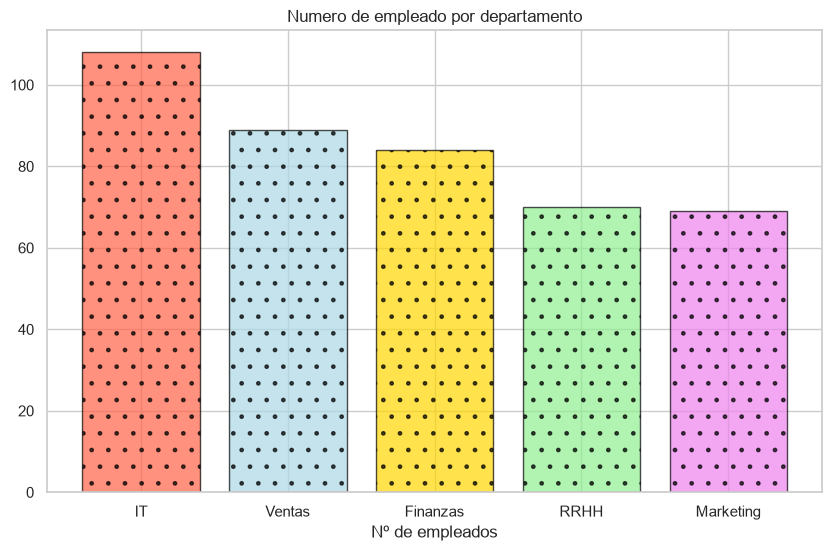

In [538]:
conteo_dpto= df['departamento'].value_counts().reset_index()
conteo_dpto.columns = ['departamento', 'cantidad']

# matplotlib
plt.figure(figsize=(10,6))
plt.title('Numero de empleado por departamento')
plt.bar( conteo_dpto['departamento'], conteo_dpto['cantidad'], alpha=0.7, edgecolor='black', color=['tomato', 'lightblue', 'gold', 'lightgreen', 'violet'], hatch='.')
plt.xlabel('Departamento')
plt.xlabel('Nº de empleados')
plt.show()

5.2 Distribucion de la edad

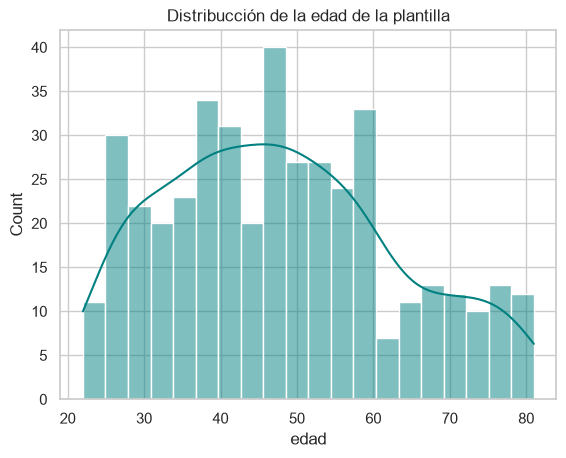

In [539]:
plt.Figure(figsize=(10,6))
plt.title('Distribucción de la edad de la plantilla')

sns.histplot(data=df, x='edad', kde=True, color='teal', bins=20)

plt.show()

5.3 Distribucion del salario

vamos a usar boxplot por que nos permite ver la mediana, rango intercuartilico y valores atipicos.

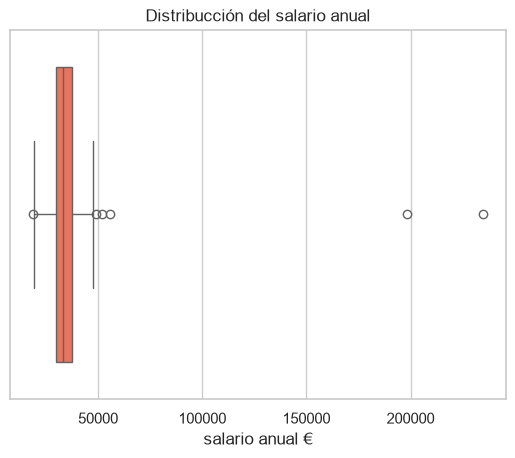

In [540]:
plt.Figure(figsize=(10,6))
plt.title('Distribucción del salario anual')
sns.boxplot(data=df, x='salario_anual', color='tomato')
plt.xlabel('salario anual €')


plt.show()

In [541]:
#quienes son esos salarios outliners que se salen de rango

df[ df['salario_anual']> 100000 ] [ ['nombre','departamento','antiguedad_anios','salario_anual']]


#Salario medio:
int(df['salario_anual'].mean())


34577

5.4 Reparto por genero

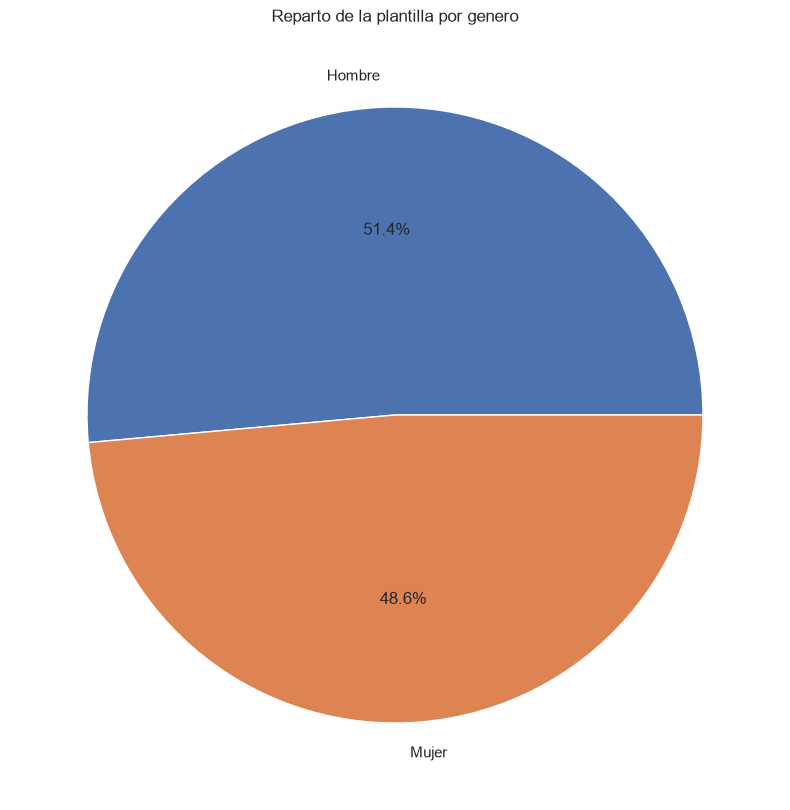

In [542]:
conteo_genero = df['genero'].value_counts()

plt.figure(figsize=(10,10))
plt.title('Reparto de la plantilla por genero')
plt.pie(conteo_genero, labels=conteo_genero.index, autopct='%1.1f%%' )

## 6. Analisis bivariante

Vamos a cruzar variables entre si para establecer relaciones.

6.1 Salario medio por departamento.

In [543]:
salario_medio_dpto = (
    df.groupby('departamento')['salario_anual'].mean().round(2)
)

salario_medio_dpto

departamento
Finanzas     37733.68
IT           37315.95
Marketing    32960.68
RRHH         31254.23
Ventas       32141.19
Name: salario_anual, dtype: float64

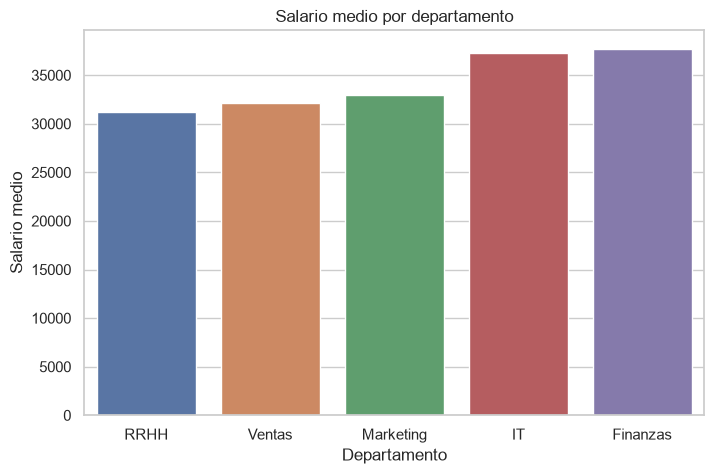

In [544]:
salario_medio_dpto = (
    df.groupby('departamento')['salario_anual']
    .mean()
    .round(2)
    .reset_index()
    .sort_values('salario_anual', ascending=True)
)
# print(salario_medio_dpto)



salario_medio_dpto = (
    df.groupby('departamento')['salario_anual']
    .mean()
    .round(2)
    .reset_index()
    .sort_values('salario_anual', ascending=True)
)
# print(salario_medio_dpto)



plt.figure(figsize=(8,5))
plt.title('Salario medio por departamento')
sns.barplot(data=salario_medio_dpto, x="departamento", y="salario_anual", hue="departamento", legend=False)
plt.xlabel('Departamento')
plt.ylabel('Salario medio')
plt.show()


plt.show()

6.2 Realcion entre edad y salario



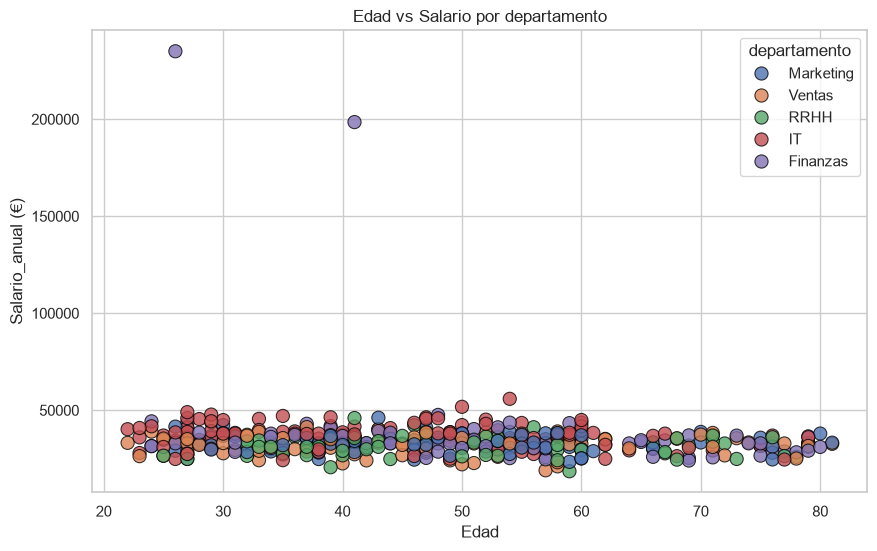

In [545]:
plt.figure(figsize=(10,6))
plt.title('Edad vs Salario por departamento')
sns.scatterplot(data=df, x='edad', y='salario_anual', hue='departamento', s=90, alpha=0.8 , edgecolor='black')
plt.xlabel('Edad')
plt.ylabel('Salario_anual (€)')
plt.show()

6.3 ¿influye el teletrabajo en la satisfaccion de los trabajodres?

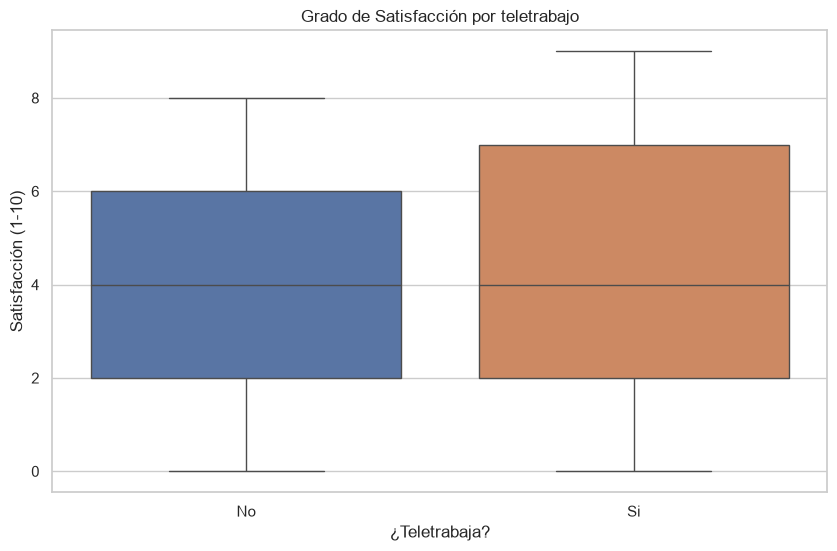

In [546]:
plt.figure(figsize=(10,6))
plt.title('Grado de Satisfacción por teletrabajo')
sns.boxplot(data=df, x="teletrabajo", y="satisfaccion", hue="teletrabajo", legend=False)
plt.xlabel('¿Teletrabaja?')
plt.ylabel('Satisfacción (1-10)')
plt.xticks([False,True],['No', 'Si'])
plt.show()

7. Correlacion entre variables numericas.
La matriz de correlacion nos dice de un vistazo que varibles numericas se mueven juntas

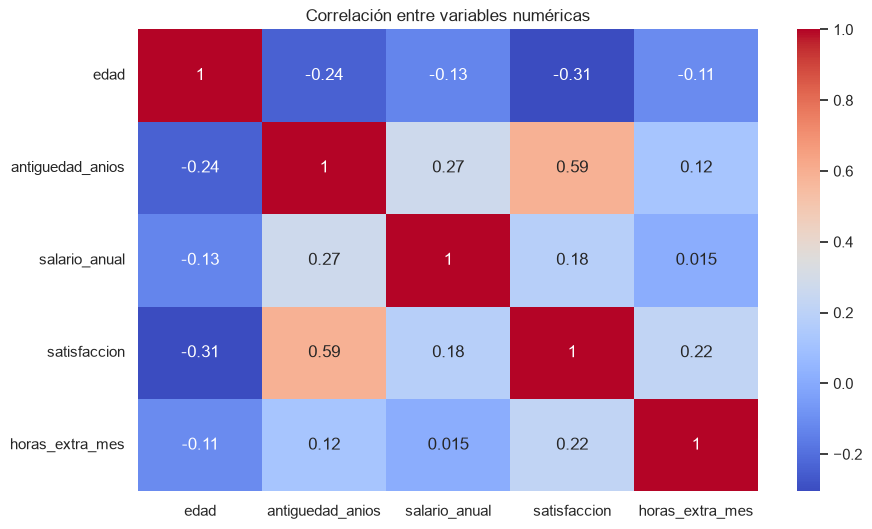

In [547]:
columnas_numericas = ['edad', 'salario_anual', 'satisfaccion', 'antiguedad_anios', 'horas_extra_mes']

columnas_numericas = ['edad', 'antiguedad_anios', 'salario_anual', 'satisfaccion', 'horas_extra_mes']
matriz_correlacion = df[columnas_numericas].corr()

plt.figure(figsize=(10, 6))
plt.title('Correlación entre variables numéricas')
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm')
plt.show()

### 8. Grafico interactivo con ploty 

Como ya sabeis con ploty podemos crear el mismo tipo de graficos pero **interactivos**:


In [548]:
fig = px.box(
    df,
    x="departamento",
    y="salario_anual",
    color='departamento',
    points="all",
    title="Distribución del salario por departamento",
    labels={'departamento': 'Departamento', 'salario_anual': 'Salario Anual (€)'}
)

fig.show()

---
## Resumen de funciones utilizadas

| Función / Sintaxis | ¿Para qué sirve? |
|---|---|
| `pd.read_csv()` | Cargar los datos |
| `df.shape` / `df.info()` / `df.describe()` | Primera exploración |
| `df.isnull().sum()` | Contar nulos por columna |
| `df.duplicated()` / `df.drop_duplicates()` | Detectar y eliminar duplicados |
| `df[col].value_counts()` | Distribución de una columna categórica |
| `.str.strip()` / `.str.upper()` / `.replace()` | Normalizar texto |
| `df[col].fillna(valor)` | Rellenar nulos |
| `df.groupby(col).transform()` | Rellenar nulos con un valor por grupo |
| `df.astype()` | Cambiar el tipo de una columna |
| `sns.barplot` / `sns.histplot` / `sns.boxplot` / `sns.scatterplot` / `sns.heatmap` | Visualización estática (seaborn) |
| `plt.pie` | Gráfico de sectores (matplotlib) |
| `df[cols].corr()` | Matriz de correlación |
| `px.box` | Gráfico interactivo (plotly) |
| `requests.get()` / `requests.post()` | Llamar a un webhook de n8n (traer datos / enviar el informe) |
---



## 9. Conclusiones

Resument de todos lo que hemos auditado

    El departamento con concretación de empleados en IT y segundo Ventas.
    El departamento que tiene el salario medio más alto es el de finanzas y luego IT.
    El salario medio en esta empresa esta en 37000 €
    El numero de hombres y mujeres esta bastante compensado cercano a 50%
    Tenemos un concentración de trabajadores en edad media de entre 37 - 47 años
    El grado de satisfación no es mucho mayor por el hecho de teletrabajar.
    Hay dos salarios muy por encima del resto (outliers) que convendría revisar con negocio.
    Unos de los departamentos más pequeños en cuanto numero de empleados condensa la mayoría de los salarios mas altos.
    La antigüedad y el salario están ligeramente relacionados a mayor mayor sueldo.
    El dataset original tenia inconsistencias, datos nulos, formato equivocados que se han tenido que limpiar.

## 10. Enviar el informe automatizado

In [549]:
conclusiones = """El departamento con concretación de empleados en IT y segundo Ventas.\nEl departamento que tiene el salario medio más alto es el de finanzas y luego IT.\nEl salario medio en esta empresa esta en 37000 €\nEl numero de hombres y mujeres esta bastante compensado cercano a 50%\nTenemos un concentración de trabajadores en edad media de entre 37 - 47 años\nEl grado de satisfación no es mucho mayor por el hecho de teletrabajar.\nHay dos salarios muy por encima del resto (outliers) que convendría revisar con negocio.\nUnos de los departamentos más pequeños en cuanto numero de empleados condensa la mayoría de los salarios mas altos.\nLa antigüedad y el salario están ligeramente relacionados a mayor mayor sueldo.\nEl dataset original tenia inconsistencias, datos nulos, formato equivocados que se han tenido que limpiar\n
"""

resumen = {
    "fecha_informe": pd.Timestamp.today().strftime('%d-%m-%Y %H:%M'),
    "total_empleados": len(df),
    "salario_medio": float(df['salario_anual'].mean().round(2)),
    "departamento_mas_grande": df['departamento'].value_counts().idxmax(),
    "numero_empleados_departamento_mas_grande":  int(df['departamento'].value_counts().max()),
    "empleados_hacen_teletrabajo": f"{int(df['teletrabajo'].mean() * 100)}%",
    "conclusiones": conclusiones
    }

URL_INFORME = 'https://david.n8ncamp.com/webhook/informe-rrhh'
response = rq.post(URL_INFORME, json=resumen, timeout=10)
print(response.json())


{'status': 'ok', 'message': 'Resumen enviado correctamente'}
